<div style="background: linear-gradient(135deg, #0f172a, #1d4ed8); padding: 24px; border-radius: 16px; color: white; margin-bottom: 20px;">
<h1 style="margin: 0;">Decomposição STL — Base 3</h1>
<p style="margin-top: 10px;">Esta etapa decompõe PM2.5 da estação Aotizhongxin em tendência, sazonalidade e resíduo, avaliando sistematicamente os parâmetros disponíveis do STL.</p>
</div>

**Objetivo:** investigar a estrutura temporal da série horária e produzir uma decomposição interpretável para a periodicidade diária escolhida.

**Decisões metodológicas aprovadas:**
- período principal: `24` observações, correspondente a um ciclo diário;
- ausências: interpolação temporal somente na cópia usada pela STL; a base de modelagem permanece sem imputação;
- `random_state=42` é registrado por consistência, embora STL seja determinístico;
- períodos, janelas, robustez, graus polinomiais e saltos serão avaliados em análise de sensibilidade.

**Modelo STL:** `observado = tendência + sazonalidade + resíduo`.

<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">1. Dados e preparação exclusiva para a STL</h2>
<p style="margin-bottom:0;">A STL requer observações equiespaçadas e sem NaN. A interpolação é restrita a esta análise descritiva, é contabilizada e não sobrescreve <code>prepared_base3.csv</code>.</p>
</div>

In [8]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from statsmodels.tsa.seasonal import STL

RANDOM_STATE = 42
TARGET = "target_pm25"
PRIMARY_PERIOD = 24
SOURCE = "https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data"


def find_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "bases" / "grupo3").exists():
            return candidate
    raise FileNotFoundError("Raiz do repositório não encontrada.")


ROOT = find_root(Path.cwd().resolve())
INPUT_PATH = ROOT / "analyses" / "grupo3" / "01_dados" / "outputs" / "prepared_base3.csv"
OUTPUT_DIR = ROOT / "analyses" / "grupo3" / "01_dados" / "outputs" / "stl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

prepared = pd.read_csv(INPUT_PATH, parse_dates=["timestamp"])
series = prepared.set_index("timestamp")[TARGET].sort_index().astype(float)
expected_index = pd.date_range(series.index.min(), series.index.max(), freq="h")
series = series.reindex(expected_index)
series.index.name = "timestamp"
if series.index.duplicated().any() or not series.index.is_monotonic_increasing:
    raise ValueError("A série não está regularizada para STL.")

missing_before = int(series.isna().sum())
series_stl = series.interpolate(method="time", limit_direction="both")
missing_after = int(series_stl.isna().sum())
if missing_after:
    raise ValueError("A interpolação não produziu uma série completa para STL.")

print(f"Série: {series.index.min()} → {series.index.max()} ({len(series):,} horas)")
print(f"Ausências originais: {missing_before:,}")
print(f"Ausências após interpolação exclusiva da STL: {missing_after}")


Série: 2013-03-01 00:00:00 → 2017-02-28 23:00:00 (35,064 horas)
Ausências originais: 925
Ausências após interpolação exclusiva da STL: 0


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">2. Parâmetros da STL</h2>
<p style="margin-bottom:0;">O período <code>24</code> é mantido como principal. As janelas são ímpares, conforme exigido pelo statsmodels, e maiores que o período quando aplicável. A configuração principal usa robustez para reduzir a influência de episódios extremos sem removê-los.</p>
</div>

In [9]:
PRIMARY_CONFIG = {
    "period": PRIMARY_PERIOD,
    "seasonal": 13,
    "trend": 169,
    "low_pass": 25,
    "seasonal_deg": 1,
    "trend_deg": 1,
    "low_pass_deg": 1,
    "robust": True,
    "seasonal_jump": 1,
    "trend_jump": 1,
    "low_pass_jump": 1,
}

parameter_documentation = pd.DataFrame([
    ("period", "24", "número de observações por ciclo sazonal; principal diário"),
    ("seasonal", "13", "janela LOESS da sazonalidade; ímpar e >= 7"),
    ("trend", "169", "janela LOESS da tendência; ímpar e maior que period"),
    ("low_pass", "25", "janela do filtro passa-baixa; ímpar e maior que period"),
    ("seasonal_deg", "0 ou 1", "grau local do polinômio da sazonalidade"),
    ("trend_deg", "0 ou 1", "grau local do polinômio da tendência"),
    ("low_pass_deg", "0 ou 1", "grau local do polinômio do filtro"),
    ("robust", "False ou True", "ponderação robusta contra observações extremas"),
    ("seasonal_jump", "1 ou 3", "salto de avaliação do LOESS sazonal"),
    ("trend_jump", "1 ou 3", "salto de avaliação do LOESS de tendência"),
    ("low_pass_jump", "1 ou 3", "salto de avaliação do filtro passa-baixa"),
], columns=["parâmetro", "valores avaliados/principal", "interpretação"])
parameter_documentation.to_csv(OUTPUT_DIR / "stl_parameter_documentation.csv", index=False)
display(parameter_documentation)


,parâmetro,valores avaliados/principal,interpretação
0,period,24,número de observações por ciclo sazonal; princ...
1,seasonal,13,janela LOESS da sazonalidade; ímpar e >= 7
2,trend,169,janela LOESS da tendência; ímpar e maior que p...
3,low_pass,25,janela do filtro passa-baixa; ímpar e maior qu...
4,seasonal_deg,0 ou 1,grau local do polinômio da sazonalidade
5,trend_deg,0 ou 1,grau local do polinômio da tendência
6,low_pass_deg,0 ou 1,grau local do polinômio do filtro
7,robust,False ou True,ponderação robusta contra observações extremas
8,seasonal_jump,1 ou 3,salto de avaliação do LOESS sazonal
9,trend_jump,1 ou 3,salto de avaliação do LOESS de tendência


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">3. Decomposição principal</h2>
<p style="margin-bottom:0;">A configuração principal é executada sobre a série interpolada somente para STL. A força da sazonalidade e da tendência é calculada como <code>max(0, 1 - Var(resíduo) / Var(resíduo + componente))</code>.</p>
</div>

In [10]:
def component_strength(result, component: str) -> float:
    if component == "seasonal":
        numerator = result.resid
        denominator = result.resid + result.seasonal
    elif component == "trend":
        numerator = result.resid
        denominator = result.resid + result.trend
    else:
        raise ValueError(component)
    denominator_variance = np.nanvar(denominator)
    if denominator_variance == 0:
        return 0.0
    return float(max(0.0, 1.0 - np.nanvar(numerator) / denominator_variance))


def fit_stl(config: dict) -> tuple[object, float]:
    started = time.perf_counter()
    result = STL(series_stl, **config).fit()
    elapsed = time.perf_counter() - started
    return result, elapsed


primary_result, primary_elapsed = fit_stl(PRIMARY_CONFIG)
primary_strength = {
    "seasonal_strength": component_strength(primary_result, "seasonal"),
    "trend_strength": component_strength(primary_result, "trend"),
}
primary_output = pd.DataFrame({
    "observed": series_stl,
    "trend": primary_result.trend,
    "seasonal": primary_result.seasonal,
    "resid": primary_result.resid,
})
primary_output.to_csv(OUTPUT_DIR / "stl_primary_components.csv", index_label="timestamp")
print({**primary_strength, "elapsed_seconds": primary_elapsed, "config": PRIMARY_CONFIG})


{'seasonal_strength': 0.013049869243193735, 'trend_strength': 0.28685557583345356, 'elapsed_seconds': 3.8079266250133514, 'config': {'period': 24, 'seasonal': 13, 'trend': 169, 'low_pass': 25, 'seasonal_deg': 1, 'trend_deg': 1, 'low_pass_deg': 1, 'robust': True, 'seasonal_jump': 1, 'trend_jump': 1, 'low_pass_jump': 1}}


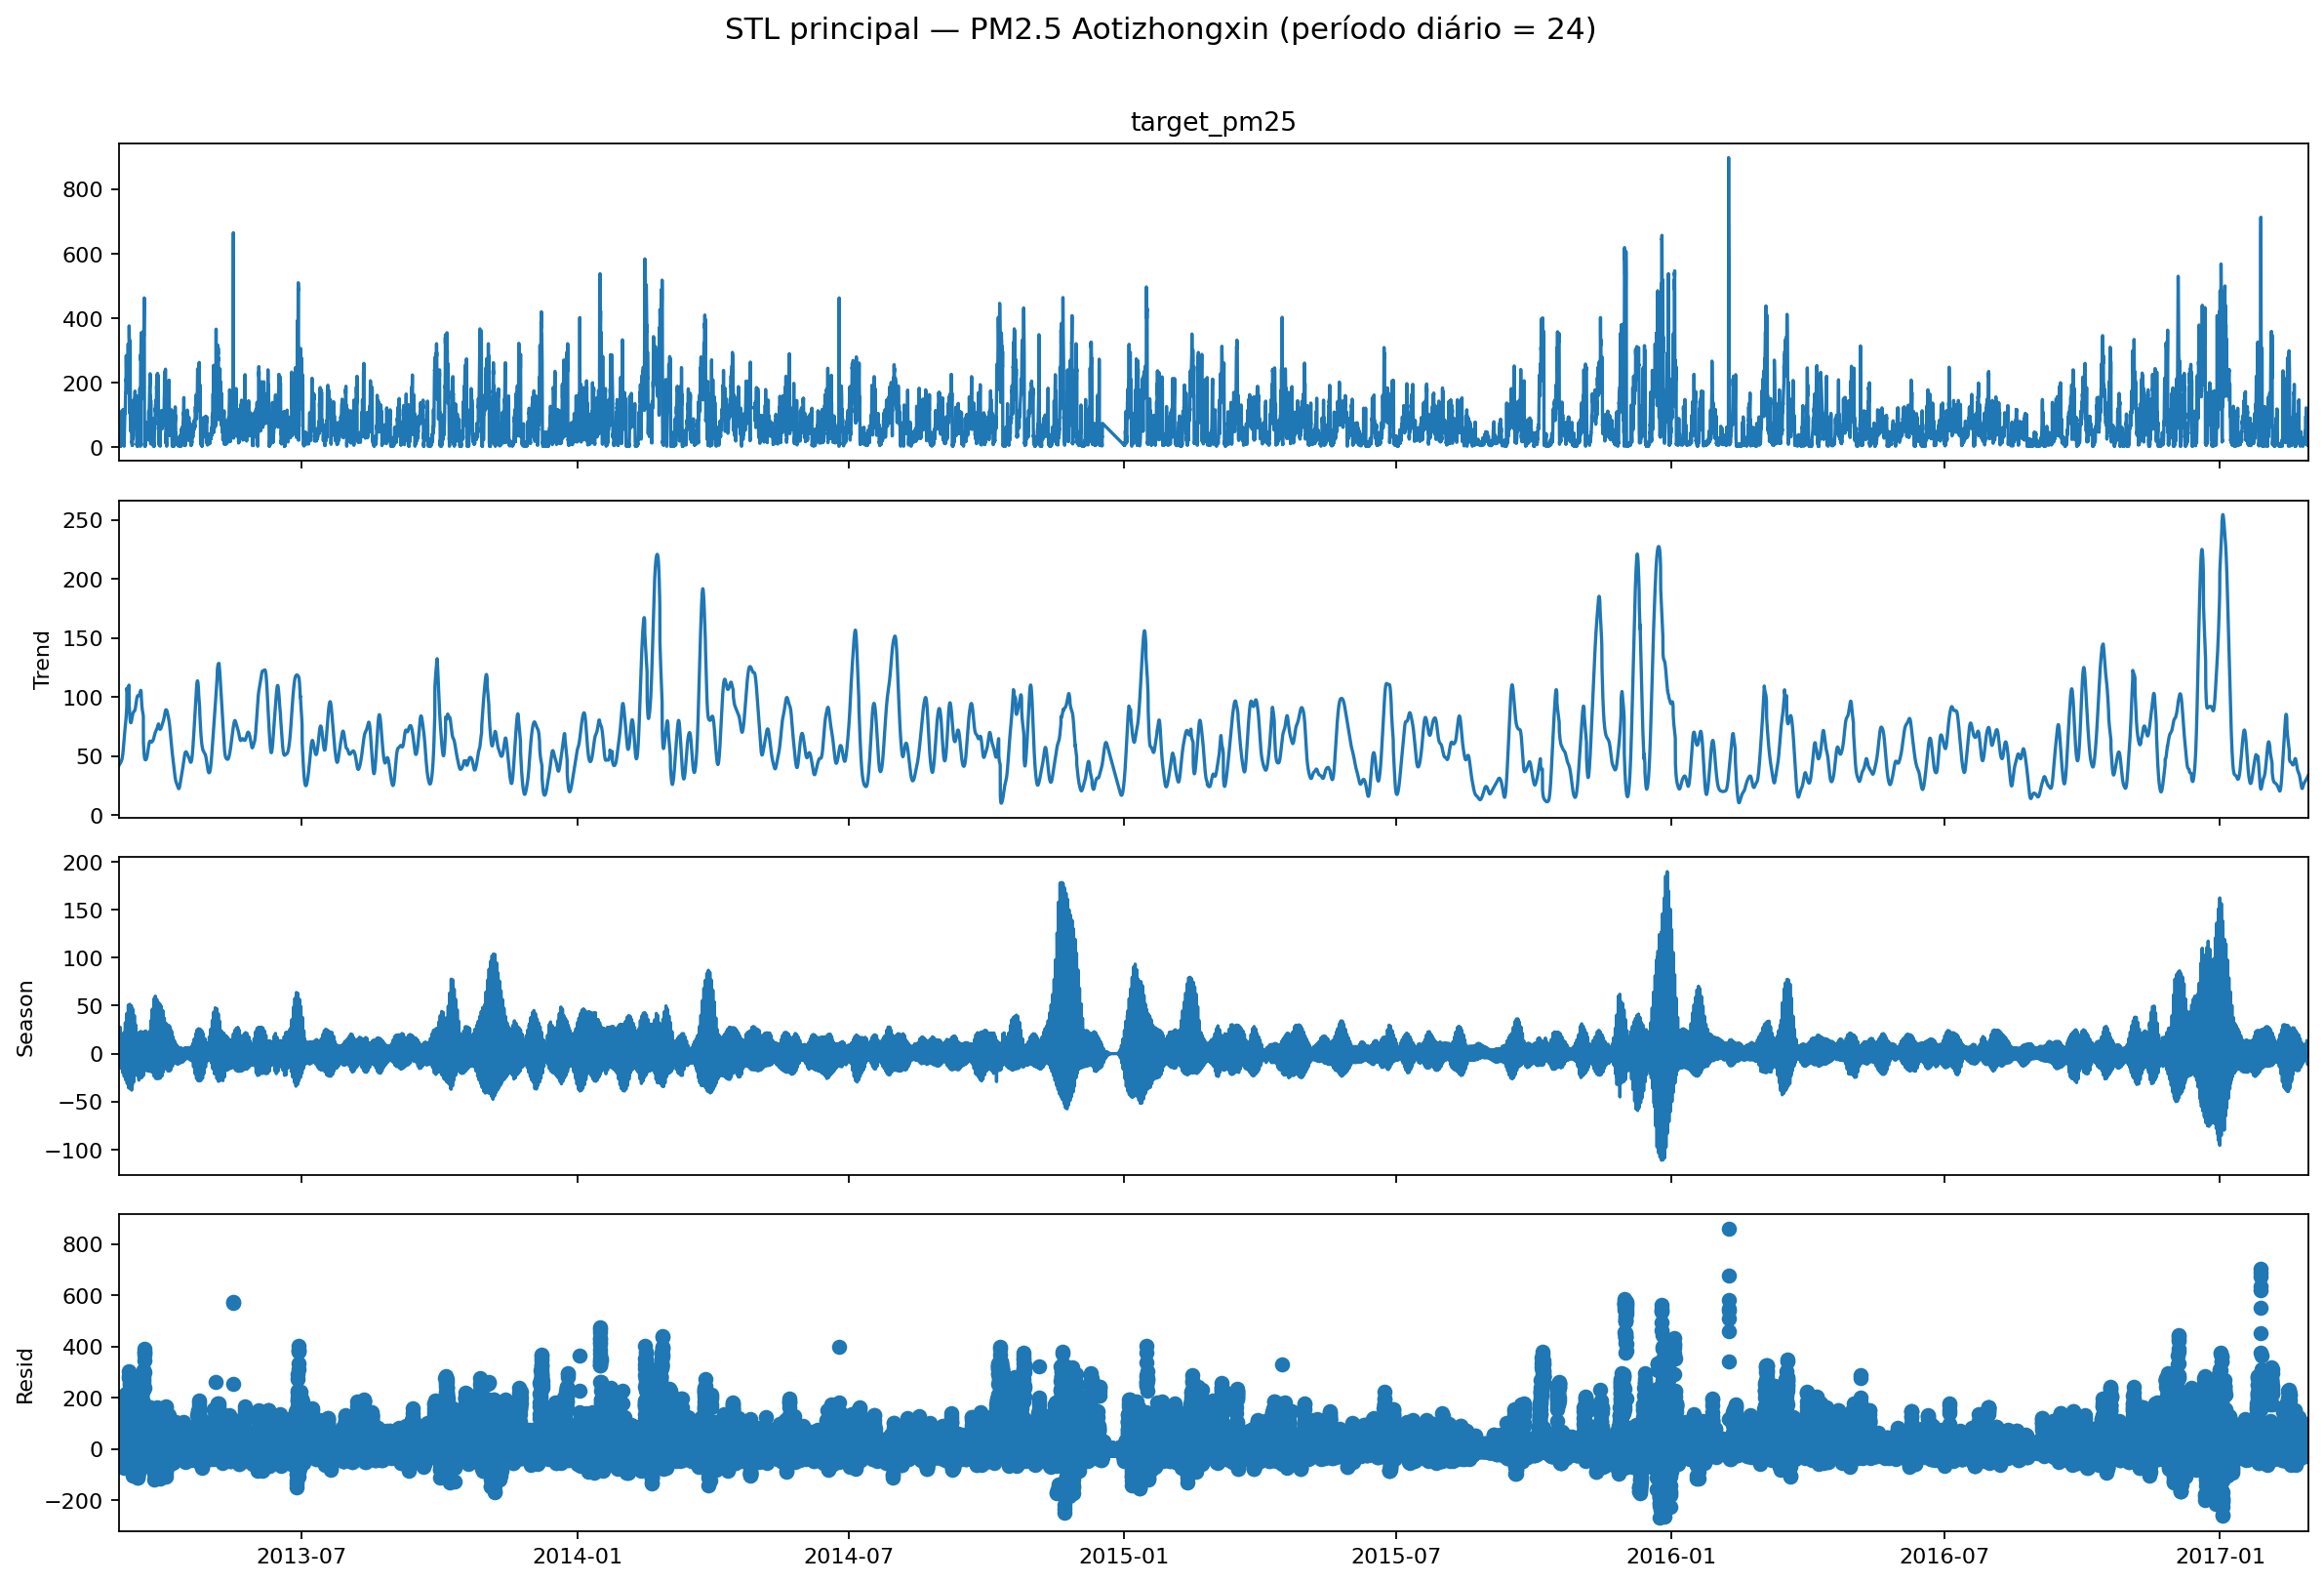

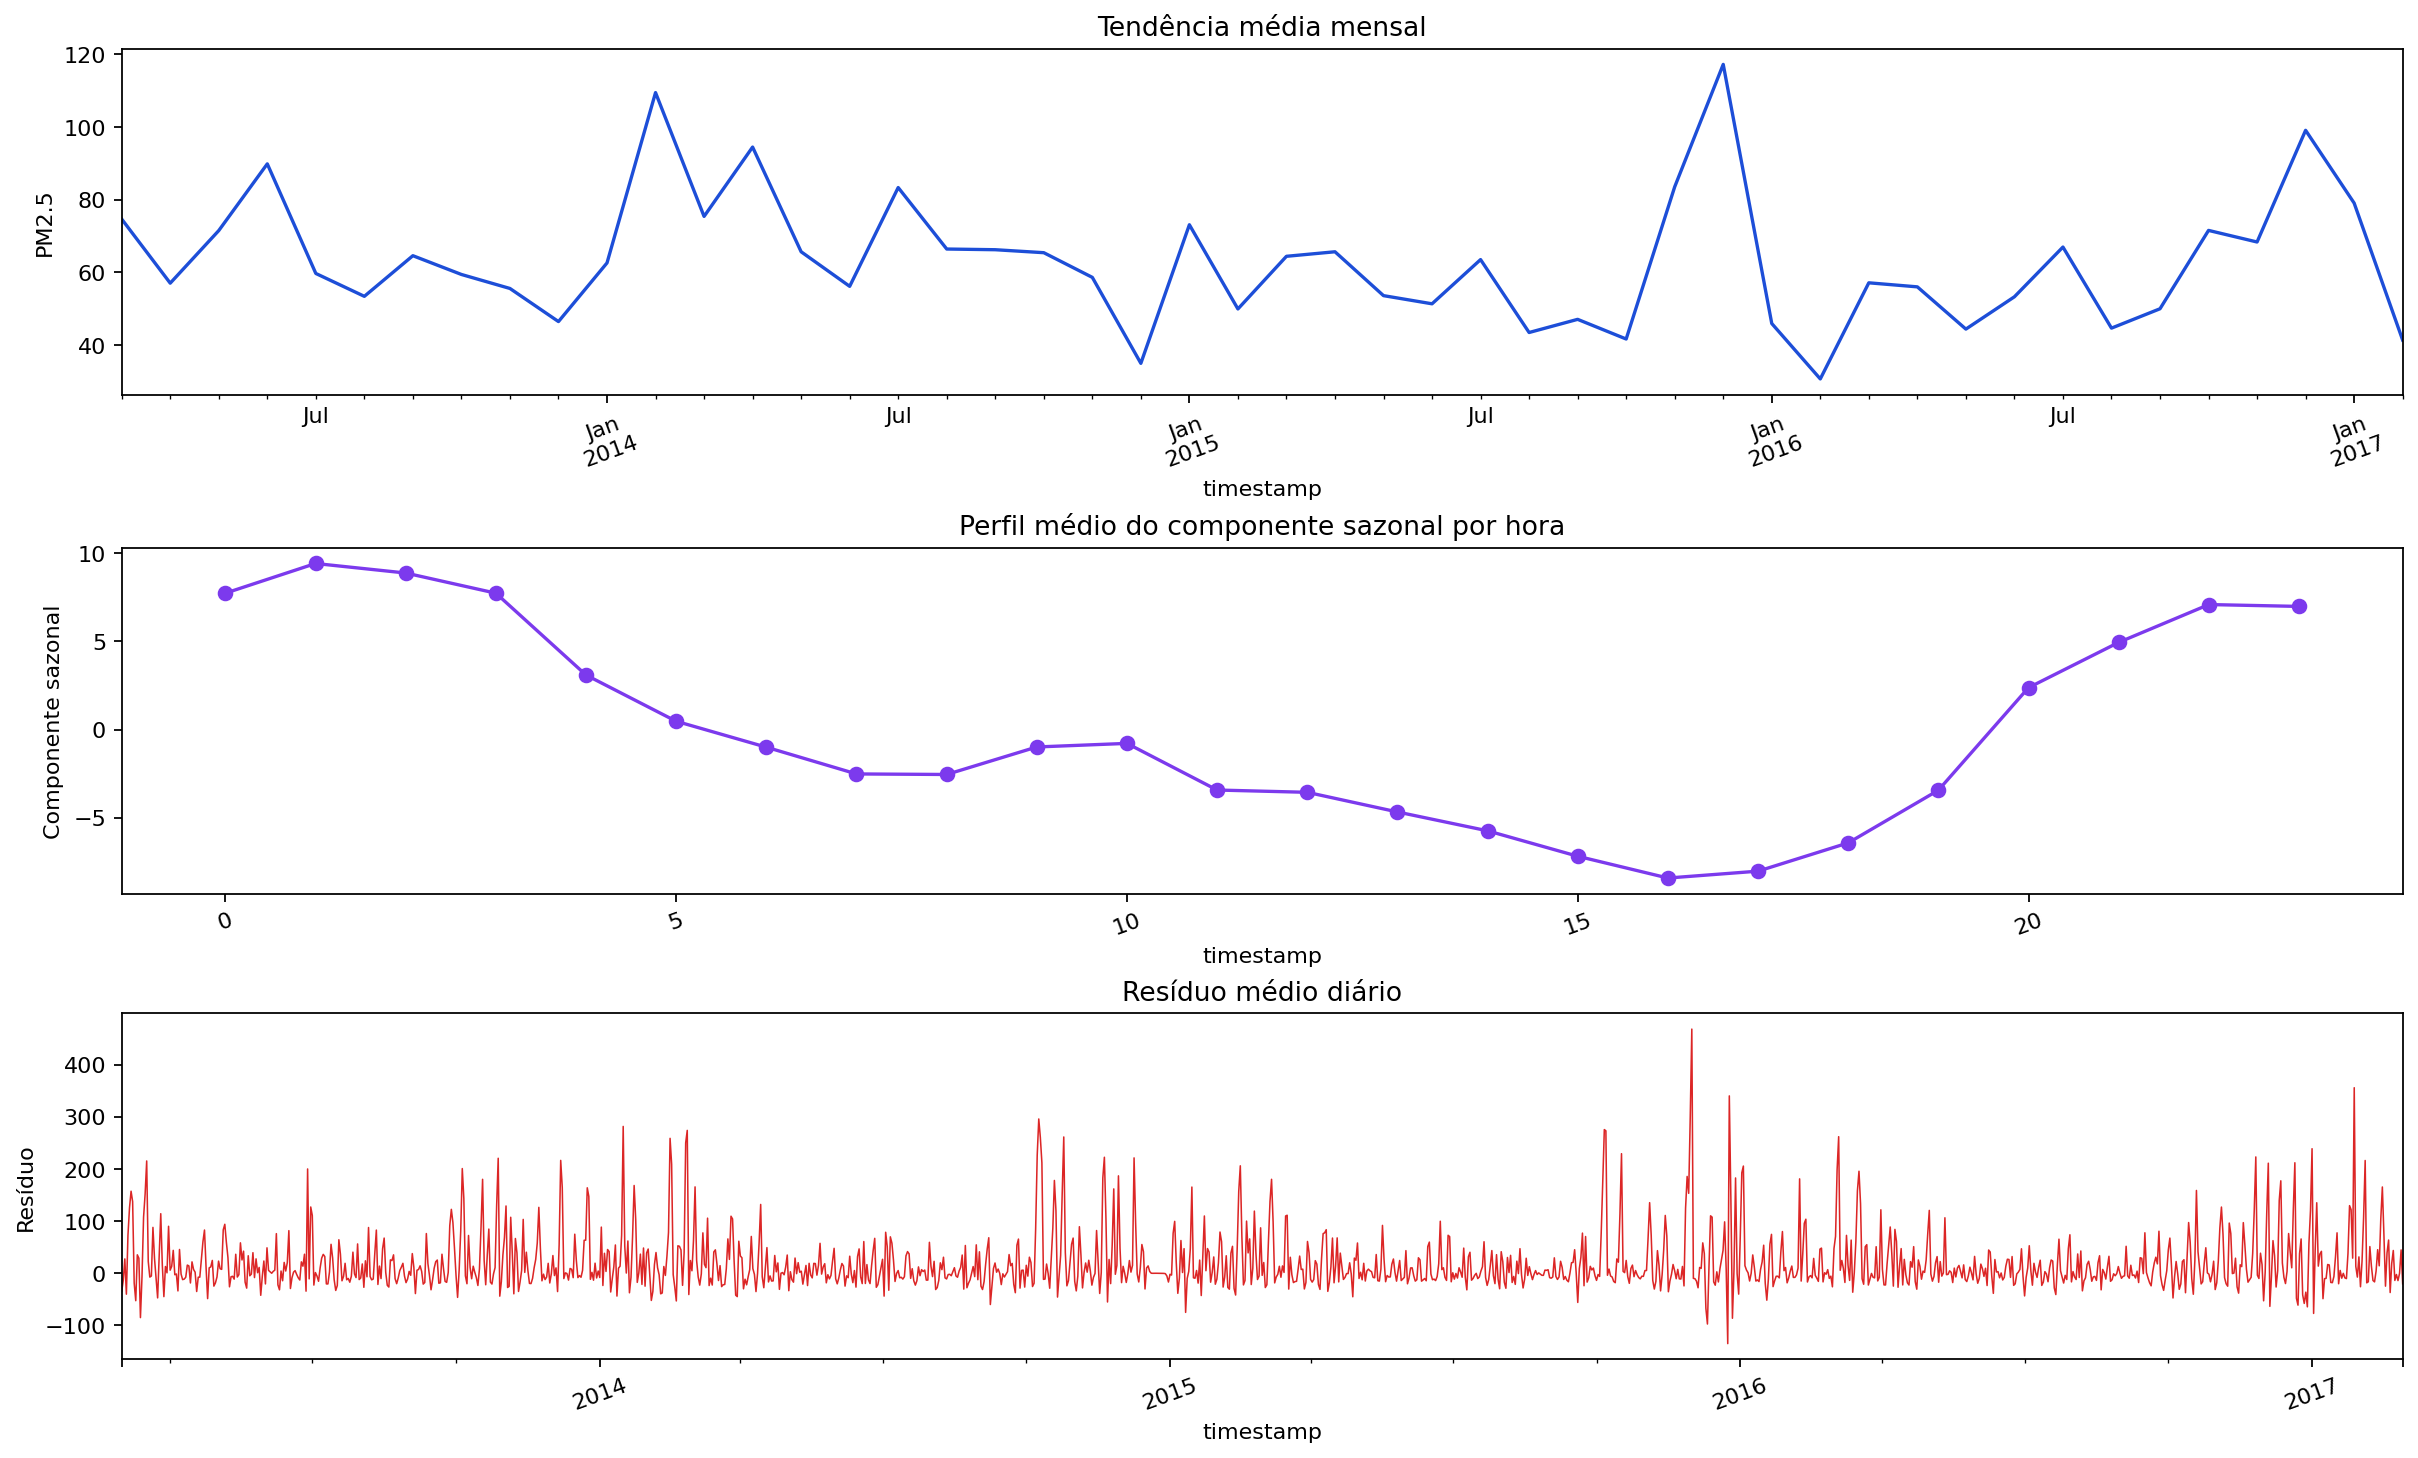

In [11]:
fig = primary_result.plot()
fig.set_size_inches(15, 10)
fig.suptitle("STL principal — PM2.5 Aotizhongxin (período diário = 24)", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "stl_primary_decomposition.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "stl_primary_decomposition.png")))
plt.close(fig)

fig, axes = plt.subplots(3, 1, figsize=(15, 9), constrained_layout=True)
primary_output["trend"].resample("MS").mean().plot(ax=axes[0], color="#1d4ed8")
axes[0].set_title("Tendência média mensal")
axes[0].set_ylabel("PM2.5")
primary_output["seasonal"].groupby(primary_output.index.hour).mean().plot(ax=axes[1], color="#7c3aed", marker="o")
axes[1].set_title("Perfil médio do componente sazonal por hora")
axes[1].set_ylabel("Componente sazonal")
primary_output["resid"].resample("D").mean().plot(ax=axes[2], color="#dc2626", linewidth=0.7)
axes[2].set_title("Resíduo médio diário")
axes[2].set_ylabel("Resíduo")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
fig.savefig(OUTPUT_DIR / "stl_primary_component_profiles.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "stl_primary_component_profiles.png")))
plt.close(fig)


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">4. Sensibilidade aos parâmetros</h2>
<p style="margin-bottom:0;">A análise varia uma dimensão por vez em torno da configuração principal. Isso permite avaliar a estabilidade da decomposição sem escolher parâmetros com base no teste de modelagem.</p>
</div>

In [12]:
sensitivity_configs = []
config_id = 0
for seasonal in [7, 13, 25]:
    for robust in [False, True]:
        sensitivity_configs.append({**PRIMARY_CONFIG, "seasonal": seasonal, "robust": robust, "config_id": config_id})
        config_id += 1
for seasonal_deg in [0, 1]:
    sensitivity_configs.append({**PRIMARY_CONFIG, "seasonal_deg": seasonal_deg, "config_id": config_id})
    config_id += 1
for trend_deg in [0, 1]:
    sensitivity_configs.append({**PRIMARY_CONFIG, "trend_deg": trend_deg, "config_id": config_id})
    config_id += 1
for low_pass_deg in [0, 1]:
    sensitivity_configs.append({**PRIMARY_CONFIG, "low_pass_deg": low_pass_deg, "config_id": config_id})
    config_id += 1
for trend_window in [169, 337]:
    sensitivity_configs.append({**PRIMARY_CONFIG, "trend": trend_window, "config_id": config_id})
    config_id += 1
for low_pass_window in [25, 49]:
    sensitivity_configs.append({**PRIMARY_CONFIG, "low_pass": low_pass_window, "config_id": config_id})
    config_id += 1
for jump in [1, 3]:
    sensitivity_configs.append({**PRIMARY_CONFIG, "seasonal_jump": jump, "trend_jump": jump, "low_pass_jump": jump, "config_id": config_id})
    config_id += 1

sensitivity_rows = []
for config in sensitivity_configs:
    run_config = {key: value for key, value in config.items() if key != "config_id"}
    result, elapsed = fit_stl(run_config)
    sensitivity_rows.append({
        "config_id": config["config_id"],
        **run_config,
        "seasonal_strength": component_strength(result, "seasonal"),
        "trend_strength": component_strength(result, "trend"),
        "residual_std": float(result.resid.std()),
        "elapsed_seconds": elapsed,
    })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity["is_primary"] = (
    (sensitivity["seasonal"] == PRIMARY_CONFIG["seasonal"]) &
    (sensitivity["robust"] == PRIMARY_CONFIG["robust"]) &
    (sensitivity["seasonal_deg"] == PRIMARY_CONFIG["seasonal_deg"]) &
    (sensitivity["trend_deg"] == PRIMARY_CONFIG["trend_deg"]) &
    (sensitivity["low_pass_deg"] == PRIMARY_CONFIG["low_pass_deg"]) &
    (sensitivity["seasonal_jump"] == PRIMARY_CONFIG["seasonal_jump"])
)
sensitivity.to_csv(OUTPUT_DIR / "stl_parameter_sensitivity.csv", index=False)
display(sensitivity.sort_values("seasonal_strength", ascending=False).head(10))


,config_id,period,seasonal,trend,low_pass,seasonal_deg,trend_deg,low_pass_deg,robust,seasonal_jump,trend_jump,low_pass_jump,seasonal_strength,trend_strength,residual_std,elapsed_seconds,is_primary
0,0,24,7,169,25,1,1,1,False,1,1,1,0.154132,0.520514,54.270774,0.560376,False
2,2,24,13,169,25,1,1,1,False,1,1,1,0.087111,0.507271,56.207499,0.586607,False
4,4,24,25,169,25,1,1,1,False,1,1,1,0.058204,0.499749,57.093731,0.597089,False
5,5,24,25,169,25,1,1,1,True,1,1,1,0.019198,0.272798,69.398478,3.854390,False
6,6,24,13,169,25,0,1,1,True,1,1,1,0.018850,0.279404,69.084733,3.626540,False
17,17,24,13,169,25,1,1,1,True,3,3,3,0.016244,0.285482,68.861462,1.216429,False
8,8,24,13,169,25,1,0,1,True,1,1,1,0.013247,0.278206,69.284179,3.467154,False
3,3,24,13,169,25,1,1,1,True,1,1,1,0.013050,0.286856,68.875678,3.690387,True
7,7,24,13,169,25,1,1,1,True,1,1,1,0.013050,0.286856,68.875678,3.632692,True
10,10,24,13,169,25,1,1,0,True,1,1,1,0.013050,0.286856,68.875678,3.610665,False


<div style="background:#eff6ff; border-left: 5px solid #2563eb; padding: 14px; border-radius: 8px; margin: 16px 0;">
<h2 style="margin-top:0; color:#1e3a8a;">5. Períodos alternativos como diagnóstico</h2>
<p style="margin-bottom:0;">O período diário 24 é o principal aprovado. Períodos semanais e subdiários são executados apenas como diagnóstico de sensibilidade da periodicidade; não substituem a decisão principal.</p>
</div>

,period,interpretacao,seasonal_strength,trend_strength,residual_std,elapsed_seconds,is_primary
0,24,diário,0.013050,0.286856,68.875678,3.682049,True
1,168,semanal,0.070839,0.157268,72.972798,9.424269,False


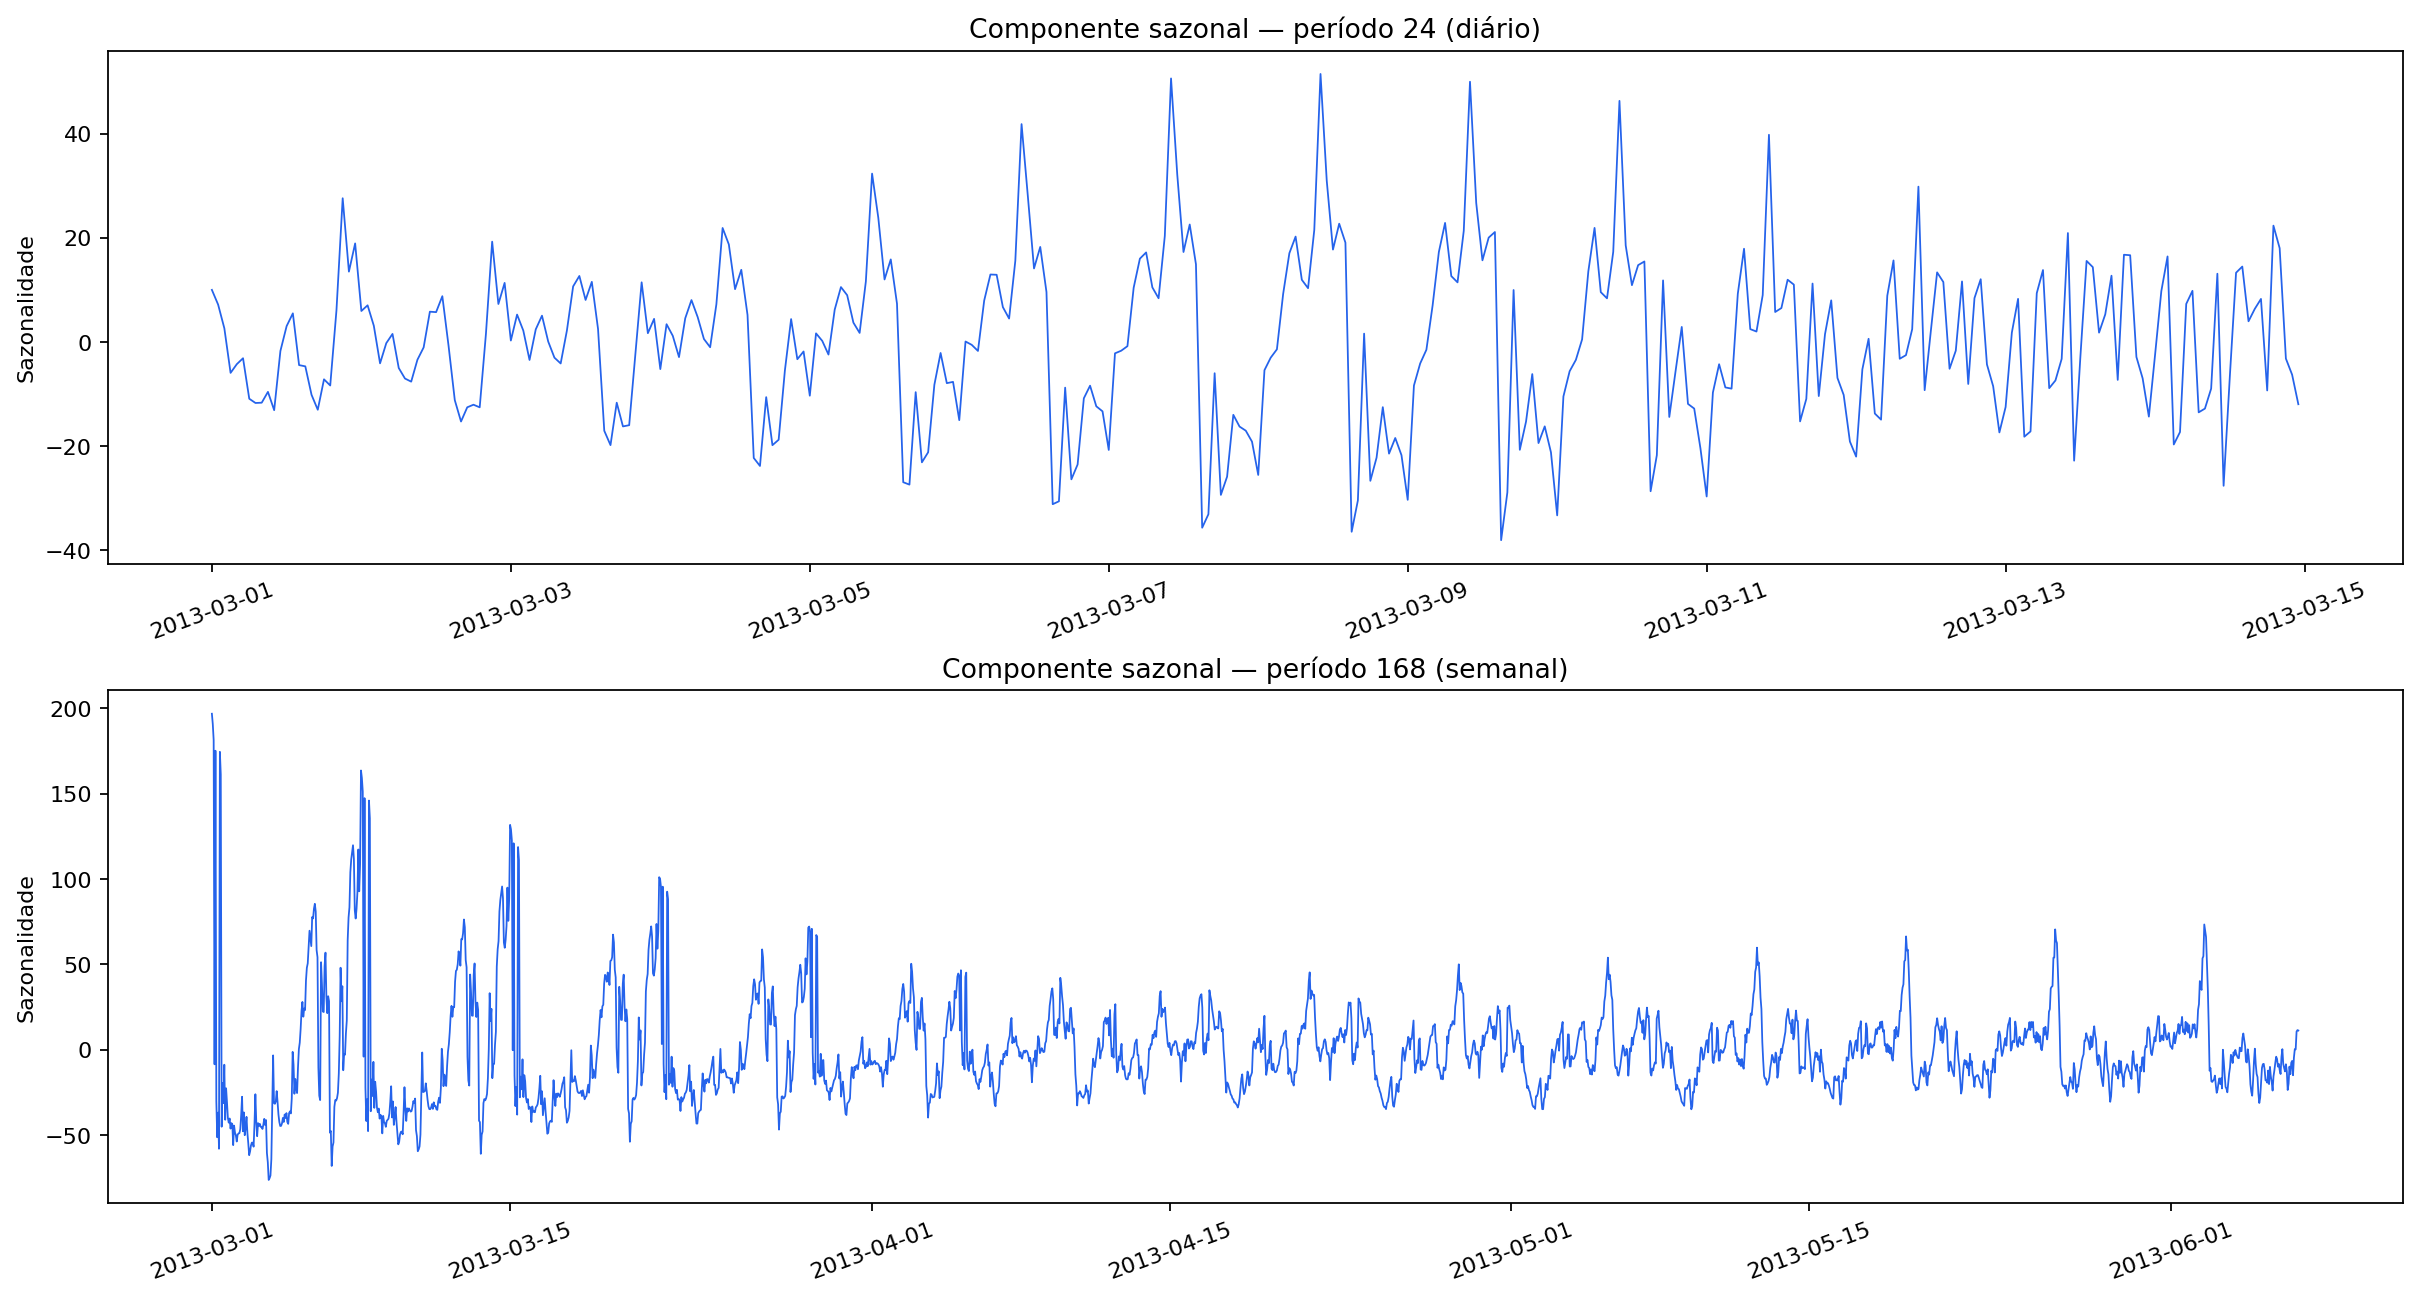

In [13]:
period_rows = []
period_results = {}
for period in [24, 168]:
    config = {**PRIMARY_CONFIG, "period": period}
    if period == 168:
        config.update({"trend": 337, "low_pass": 169})
    result, elapsed = fit_stl(config)
    period_results[period] = result
    period_rows.append({
        "period": period,
        "interpretacao": "diário" if period == 24 else "semanal",
        "seasonal_strength": component_strength(result, "seasonal"),
        "trend_strength": component_strength(result, "trend"),
        "residual_std": float(result.resid.std()),
        "elapsed_seconds": elapsed,
        "is_primary": period == PRIMARY_PERIOD,
    })
period_comparison = pd.DataFrame(period_rows)
period_comparison.to_csv(OUTPUT_DIR / "stl_period_comparison.csv", index=False)
display(period_comparison)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)
for ax, period in zip(axes, [24, 168]):
    seasonal_profile = period_results[period].seasonal.iloc[:period * 14]
    ax.plot(seasonal_profile.index, seasonal_profile, color="#2563eb", linewidth=0.8)
    ax.set_title(f"Componente sazonal — período {period} ({'diário' if period == 24 else 'semanal'})")
    ax.set_ylabel("Sazonalidade")
    ax.tick_params(axis="x", rotation=20)
fig.savefig(OUTPUT_DIR / "stl_periods_seasonal_components.png", dpi=160, bbox_inches="tight")
display(Image(filename=str(OUTPUT_DIR / "stl_periods_seasonal_components.png")))
plt.close(fig)


<div style="background:#dbeafe; border-radius: 12px; padding: 16px; color:#1e3a8a;">
<h2 style="margin-top:0;">Interpretação e reprodutibilidade</h2>
<p>Os valores numéricos da decomposição, das forças e da sensibilidade são salvos em CSV e no manifesto. A interpretação deve usar esses resultados executados, sem conclusões hardcoded.</p>
<ul style="margin-bottom:0;">
<li>Tendência: avaliada pelo componente <code>trend</code> e pela força de tendência.</li>
<li>Sazonalidade: avaliada principalmente no ciclo diário de 24 horas.</li>
<li>Resíduos: avaliados por dispersão e comportamento temporal; testes formais ficam na etapa de resultados.</li>
<li>Valores extremos são preservados; <code>robust=True</code> altera a ponderação do ajuste, não remove observações.</li>
</ul>
</div>

In [14]:
manifest = {
    "source": SOURCE,
    "input_file": str(INPUT_PATH.relative_to(ROOT)),
    "output_directory": str(OUTPUT_DIR.relative_to(ROOT)),
    "target": TARGET,
    "primary_period": PRIMARY_PERIOD,
    "primary_config": PRIMARY_CONFIG,
    "missing_values_original": missing_before,
    "missing_values_after_stl_interpolation": missing_after,
    "stl_interpolation_scope": "exclusive to STL copy; modeling base unchanged",
    "random_state": RANDOM_STATE,
    "parameter_sensitivity": {
        "seasonal_windows": [7, 13, 25],
        "robust": [False, True],
        "degrees": [0, 1],
        "trend_windows": [169, 337],
        "low_pass_windows": [25, 49],
        "jumps": [1, 3],
        "diagnostic_periods": [24, 168],
    },
    "primary_strength": primary_strength,
    "outputs": [
        "stl_primary_components.csv",
        "stl_parameter_documentation.csv",
        "stl_parameter_sensitivity.csv",
        "stl_period_comparison.csv",
        "stl_primary_decomposition.png",
        "stl_primary_component_profiles.png",
        "stl_periods_seasonal_components.png",
    ],
}
with (OUTPUT_DIR / "stl_manifest.json").open("w", encoding="utf-8") as file:
    json.dump(manifest, file, ensure_ascii=False, indent=2)
print(json.dumps(manifest, ensure_ascii=False, indent=2))


{
  "source": "https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data",
  "input_file": "analyses/grupo3/01_dados/outputs/prepared_base3.csv",
  "output_directory": "analyses/grupo3/01_dados/outputs/stl",
  "target": "target_pm25",
  "primary_period": 24,
  "primary_config": {
    "period": 24,
    "seasonal": 13,
    "trend": 169,
    "low_pass": 25,
    "seasonal_deg": 1,
    "trend_deg": 1,
    "low_pass_deg": 1,
    "robust": true,
    "seasonal_jump": 1,
    "trend_jump": 1,
    "low_pass_jump": 1
  },
  "missing_values_original": 925,
  "missing_values_after_stl_interpolation": 0,
  "stl_interpolation_scope": "exclusive to STL copy; modeling base unchanged",
  "random_state": 42,
  "parameter_sensitivity": {
    "seasonal_windows": [
      7,
      13,
      25
    ],
    "robust": [
      false,
      true
    ],
    "degrees": [
      0,
      1
    ],
    "trend_windows": [
      169,
      337
    ],
    "low_pass_windows": [
      25,
      49
    ],
   